In [2]:
import pandas as pd
import os

RAW = "../data/raw"

for f in sorted(os.listdir(RAW)):
    if not f.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(RAW, f), nrows=3)
    print(f"\n=== {f} ===")
    print("Columns:", list(df.columns))


=== CEAS_08.csv ===
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

=== Enron.csv ===
Columns: ['subject', 'body', 'label']

=== Ling.csv ===
Columns: ['subject', 'body', 'label']

=== Nazario.csv ===
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

=== Nigerian_Fraud.csv ===
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

=== SpamAssasin.csv ===
Columns: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

=== phishing_email.csv ===
Columns: ['text_combined', 'label']


In [3]:
df = pd.read_csv("../data/raw/phishing_email.csv")

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nProportions:")
print(df["label"].value_counts(normalize=True).round(3))
print("\nMissing values:")
print(df.isnull().sum())
print("\nExact duplicate rows:", df.duplicated().sum())
print("Duplicate texts:", df["text_combined"].duplicated().sum())


Shape: (82486, 2)

Label distribution:
label
1    42891
0    39595
Name: count, dtype: int64

Proportions:
label
1    0.52
0    0.48
Name: proportion, dtype: float64

Missing values:
text_combined    0
label            0
dtype: int64

Exact duplicate rows: 408
Duplicate texts: 408


In [4]:
# Which label means what?
for lbl in sorted(df["label"].unique()):
    print(f"\n{'='*60}")
    print(f"LABEL = {lbl}")
    print('='*60)
    for txt in df[df["label"] == lbl]["text_combined"].head(2):
        print(f"\n{str(txt)[:400]}")
        print("-" * 40)

# Empty or whitespace-only text
blank = df["text_combined"].astype(str).str.strip().eq("").sum()
print(f"\n\nBlank/whitespace-only texts: {blank}")


LABEL = 0

hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls
----------------------------------------

nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nomination 33 750 forwarded eileen ponton houston pefs pec 05 29 01 08 36 charlie stone eileen ponton melissa
----------------------------------------

LABEL = 1

link dwl g 510 802 11 g wireless pci lan adapter 39 85 39 85 dwl g 510 high speed 2 4 ghz 802 11 g wireless pci lan adapter ieee 802 11 g standardupto 54 mbpsoperating frequency range 2 4 ghz ideal solution enabling wireless networking capabilities desktops pcs home office dwl g 510 visit http www computron com deals link dwl g 510 802 11 g wireless pci lan adapter link g 510 wireless pci adapter 
-------------------------

In [1]:
import pandas as pd

for f in ["CEAS_08.csv", "Nazario.csv", "SpamAssasin.csv", "Enron.csv"]:
    d = pd.read_csv(f"../data/raw/{f}", nrows=2)
    print(f"\n{'='*60}\n{f}\n{'='*60}")
    print("SUBJECT:", repr(str(d['subject'].iloc[0])[:100]))
    print("\nBODY:", repr(str(d['body'].iloc[0])[:350]))


CEAS_08.csv
SUBJECT: 'Never agree to be a loser'

BODY: 'Buck up, your troubles caused by small dimension will soon be over!\nBecome a lover no woman will be able to resist!\nhttp://whitedone.com/\n\n\ncome. Even as Nazi tanks were rolling down the streets, the dreamersphilosopher or a journalist. He was still not sure.I do the same.'

Nazario.csv
SUBJECT: "DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA"

BODY: 'This text is part of the internal format of your mail folder, and is not a real message.  It is created automatically by the mail system software. If deleted, important folder data will be lost, and it will be re-created with the data reset to initial values. From 125117@ihp-osb-lngweb5.ihp.iinet.net.au  Fri Jan  2 07:19:00 2015 Return-Path: <12511'

SpamAssasin.csv
SUBJECT: 'Re: New Sequences Window'

BODY: "Date:        Wed, 21 Aug 2002 10:54:46 -0500     From:        Chris Garrigues      Message-ID:  <1029945287.4797.TMDA@deepeddy.vircio.com>   | I can't reproduce this e

In [5]:
import pandas as pd

files = ["CEAS_08.csv", "Enron.csv", "Ling.csv", "Nazario.csv",
         "Nigerian_Fraud.csv", "SpamAssasin.csv"]

for f in files:
    d = pd.read_csv(f"../data/raw/{f}", usecols=["body", "label"])
    b = d["body"].astype(str)
    n = len(d)
    print(f"\n=== {f} ===")
    print(f"rows={n}   spam={(d.label==1).sum()}  ham={(d.label==0).sum()}"
          f"   spam%={100*(d.label==1).mean():.1f}")
    print(f"has uppercase : {100*b.str.contains(r'[A-Z]', regex=True).mean():.1f}%")
    print(f"has '!'       : {100*b.str.contains('!', regex=False).mean():.1f}%")
    print(f"has 'http'    : {100*b.str.contains('http', regex=False).mean():.1f}%")


=== CEAS_08.csv ===
rows=39154   spam=21842  ham=17312   spam%=55.8
has uppercase : 98.6%
has '!'       : 34.5%
has 'http'    : 67.1%

=== Enron.csv ===
rows=29767   spam=13976  ham=15791   spam%=47.0
has uppercase : 0.0%
has '!'       : 32.8%
has 'http'    : 18.8%

=== Ling.csv ===
rows=2859   spam=458  ham=2401   spam%=16.0
has uppercase : 0.0%
has '!'       : 25.0%
has 'http'    : 38.8%

=== Nazario.csv ===
rows=1565   spam=1565  ham=0   spam%=100.0
has uppercase : 99.0%
has '!'       : 11.4%
has 'http'    : 12.7%

=== Nigerian_Fraud.csv ===
rows=3332   spam=3332  ham=0   spam%=100.0
has uppercase : 99.9%
has '!'       : 28.1%
has 'http'    : 33.2%

=== SpamAssasin.csv ===
rows=5809   spam=1718  ham=4091   spam%=29.6
has uppercase : 99.8%
has '!'       : 45.8%
has 'http'    : 78.8%


In [6]:
df = pd.read_csv("../data/raw/phishing_email.csv")
t = df["text_combined"].astype(str)

for pat, name in [(r'[A-Z]', 'uppercase'), (r'!', 'exclamation'),
                  (r'\?', 'question mark'), (r'http', 'http'),
                  (r'www', 'www'), (r'\d', 'digit'), (r'[.,]', 'period/comma')]:
    print(f"{name:15s}: {100*t.str.contains(pat, regex=True).mean():5.1f}%")

uppercase      :   0.0%
exclamation    :   0.0%
question mark  :   0.0%
http           :  47.2%
www            :  22.8%
digit          :  94.2%
period/comma   :   0.0%


In [7]:
print("Before:", df.shape)

# 1. Drop duplicates — prevents train/test leakage
df = df.drop_duplicates(subset="text_combined").reset_index(drop=True)
print("After dedup:", df.shape)

# 2. Drop blank/whitespace-only text
df = df[df["text_combined"].astype(str).str.strip() != ""].reset_index(drop=True)
print("After blank removal:", df.shape)

# 3. Normalize whitespace and ensure string type
df["text"] = (df["text_combined"].astype(str)
              .str.replace(r"\s+", " ", regex=True)
              .str.strip())

print("\nFinal shape:", df.shape)
print("\nClass balance:")
print(df["label"].value_counts(normalize=True).round(3))

df[["text", "label"]].to_csv("../data/processed/cleaned.csv", index=False)
print("\nSaved to data/processed/cleaned.csv")

Before: (82486, 2)
After dedup: (82078, 2)
After blank removal: (82077, 2)

Final shape: (82077, 3)

Class balance:
label
1    0.522
0    0.478
Name: proportion, dtype: float64

Saved to data/processed/cleaned.csv


label                 0          1
n_chars count   39233.0    42844.0
        mean     1541.5     1060.7
        std      3711.5    21204.3
        min        10.0        2.0
        25%       411.0      241.0
        50%       780.0      391.0
        75%      1495.0     1058.0
        max    160318.0  4279526.0
n_words count   39233.0    42844.0
        mean      203.7      121.4
        std       481.2      594.8
        min         2.0        1.0
        25%        57.0       32.0
        50%       106.0       55.0
        75%       203.0      154.0
        max     23359.0   107710.0


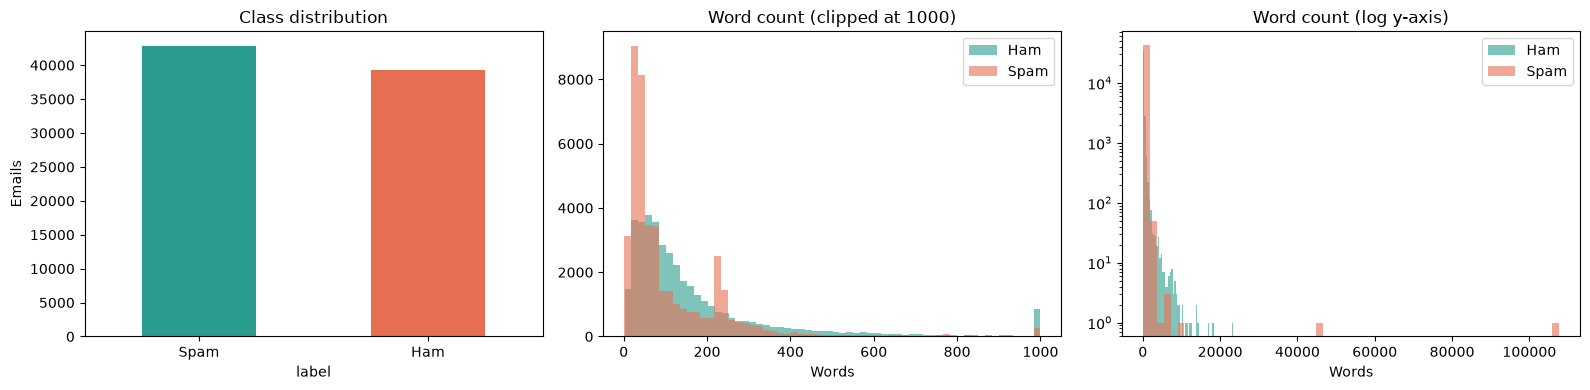

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].str.split().str.len()

print(df.groupby("label")[["n_chars", "n_words"]].describe().round(1).T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class balance
df["label"].map({0: "Ham", 1: "Spam"}).value_counts().plot(
    kind="bar", ax=axes[0], color=["#2a9d8f", "#e76f51"])
axes[0].set_title("Class distribution")
axes[0].set_ylabel("Emails")
axes[0].tick_params(axis="x", rotation=0)

# Word count, clipped at 1000 so outliers don't flatten the plot
for lbl, name, c in [(0, "Ham", "#2a9d8f"), (1, "Spam", "#e76f51")]:
    axes[1].hist(df[df.label == lbl]["n_words"].clip(upper=1000),
                 bins=60, alpha=0.6, label=name, color=c)
axes[1].set_title("Word count (clipped at 1000)")
axes[1].set_xlabel("Words")
axes[1].legend()

# Log scale reveals the tail shape
for lbl, name, c in [(0, "Ham", "#2a9d8f"), (1, "Spam", "#e76f51")]:
    axes[2].hist(df[df.label == lbl]["n_words"], bins=60,
                 alpha=0.6, label=name, color=c, log=True)
axes[2].set_title("Word count (log y-axis)")
axes[2].set_xlabel("Words")
axes[2].legend()

plt.tight_layout()
plt.savefig("../results/class_and_length_distribution.png", dpi=120)
plt.show()

In [10]:
print("=== LONGEST 5 ===")
for i, r in df.nlargest(5, "n_chars").iterrows():
    print(f"label={r.label}  chars={r.n_chars:,}  words={r.n_words:,}")
    print(f"  {r.text[:200]}\n")

print("\n=== SHORTEST 10 ===")
for i, r in df.nsmallest(10, "n_words").iterrows():
    print(f"label={r.label}  words={r.n_words}  text={r.text[:100]!r}")

print("\n=== How many are very short? ===")
for n in [1, 2, 3, 5, 10]:
    sub = df[df.n_words <= n]
    print(f"<= {n:2d} words: {len(sub):5d} rows  "
          f"(spam={(sub.label==1).sum()}, ham={(sub.label==0).sum()})")


=== LONGEST 5 ===
label=1  chars=4,279,526  words=107,710
  mail system internal data mailerdaemonmonkeyorg text part internal format mail folder real message created automatically mail system software deleted important folder data lost recreated data reset in

label=1  chars=868,304  words=46,425
  email administrator security_updatewebmailcom security alert dear 0537324880001tonlinede 05af04navygovau 06af06navygovau 072477202tonlinede 0853043094teliacom 10001271compuservecom 1001013220compuserv

label=1  chars=225,918  words=3,193
  adverting department advertsprj40cscom multipart message mime format _nextpart_000_01bc2b7489d1ccc0 contenttype multipartalternative boundary_nextpart_84815c5abaf209ef376268c8 _nextpart_84815c5abaf209

label=1  chars=178,647  words=2,423
  freeidddogmaslashnullorg multipart message mime format _nextpart_7hzmysbwvsemnjin8kg9y contenttype multipartalternative boundary_nextpart_7hzmysbwvsemnjin8kg9yaa _nextpart_7hzmysbwvsemnjin8kg9yaa cont

label=0  chars=16

In [11]:
print("Before:", len(df))

# Drop 1-word rows: no usable signal
df = df[df.n_words >= 2].reset_index(drop=True)
print("After dropping 1-word:", len(df))

# Cap extreme length: keeps genuine long email, removes parsing artifacts
CAP = 20000
print(f"\nRows above {CAP} words: {(df.n_words > CAP).sum()}")
print(df[df.n_words > CAP][["label", "n_words"]])

df = df[df.n_words <= CAP].reset_index(drop=True)
print("\nAfter length cap:", len(df))
print(df["label"].value_counts(normalize=True).round(3))

Before: 82077
After dropping 1-word: 82074

Rows above 20000 words: 3
       label  n_words
11052      0    23359
80509      1   107710
81042      1    46425

After length cap: 82071
label
1    0.522
0    0.478
Name: proportion, dtype: float64


In [12]:
df = pd.read_csv("../data/processed/cleaned.csv")
df["n_words"] = df["text"].astype(str).str.split().str.len()
df["n_chars"] = df["text"].astype(str).str.len()

df = df[df.n_words >= 2].reset_index(drop=True)

CAP = 30000
print("Rows above cap:")
print(df[df.n_words > CAP][["label", "n_words"]])

df = df[df.n_words <= CAP].reset_index(drop=True)

print("\nFinal:", len(df))
print(df["label"].value_counts(normalize=True).round(3))
print("\nMedian words by class:")
print(df.groupby("label")["n_words"].median())

df[["text", "label"]].to_csv("../data/processed/cleaned.csv", index=False)
print("\nSaved.")

Rows above cap:
       label  n_words
80509      1   107710
81042      1    46425

Final: 82072
label
1    0.522
0    0.478
Name: proportion, dtype: float64

Median words by class:
label
0    106.0
1     55.0
Name: n_words, dtype: float64

Saved.


In [13]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

cv = CountVectorizer(min_df=20, max_features=30000)
X = cv.fit_transform(df["text"].astype(str))
vocab = cv.get_feature_names_out()

spam_mask = (df["label"] == 1).values
ham_mask = ~spam_mask

# Fraction of emails in each class containing the word
spam_rate = (X[spam_mask] > 0).mean(axis=0).A1
ham_rate = (X[ham_mask] > 0).mean(axis=0).A1

freq = pd.DataFrame({
    "word": vocab,
    "spam_pct": 100 * spam_rate,
    "ham_pct": 100 * ham_rate,
})
freq["lift"] = (freq.spam_pct + 0.5) / (freq.ham_pct + 0.5)

print("Vocabulary size:", len(vocab))
print("\n--- Most SPAM-skewed (min 3% of spam emails) ---")
print(freq[freq.spam_pct > 3].nlargest(25, "lift")
      .round(2).to_string(index=False))

print("\n--- Most HAM-skewed (min 3% of ham emails) ---")
print(freq[freq.ham_pct > 3].nsmallest(25, "lift")
      .round(2).to_string(index=False))

Vocabulary size: 27155

--- Most SPAM-skewed (min 3% of spam emails) ---
                           word  spam_pct  ham_pct  lift
                          30303     10.12     0.03 20.21
                         cnncom     10.12     0.04 19.74
                            cnn     10.63     0.14 17.52
          httpwwwcnncomfeedback      6.84     0.00 14.68
httpwwwcnncomlinktobnmanagehtml      6.84     0.00 14.68
       httpwwwcnncomprivacyhtml      6.84     0.00 14.68
                           lllp      6.84     0.00 14.68
                        atlanta     10.28     0.25 14.27
                         warner     10.16     0.35 12.55
                        georgia     10.34     0.39 12.15
                        watches      6.12     0.07 11.68
                            358      6.85     0.17 10.91
                          cable     10.66     0.59 10.23
                        replica      5.39     0.09 10.05
                        trusted      7.56     0.37  9.30
               

In [14]:
# Terms that are near-perfectly predictive are almost always artifacts,
# not language. Real spam words appear in both classes, just unevenly.
extreme = freq[
    ((freq.spam_pct > 2) & (freq.ham_pct < 0.15)) |
    ((freq.ham_pct  > 2) & (freq.spam_pct < 0.15))
].copy()

extreme["side"] = ["spam" if s > h else "ham"
                   for s, h in zip(extreme.spam_pct, extreme.ham_pct)]

print("Candidate artifact terms:", len(extreme))
print("\n--- spam side ---")
print(extreme[extreme.side == "spam"].nlargest(40, "spam_pct")
      .round(2).to_string(index=False))
print("\n--- ham side ---")
print(extreme[extreme.side == "ham"].nlargest(40, "ham_pct")
      .round(2).to_string(index=False))

Candidate artifact terms: 255

--- spam side ---
                           word  spam_pct  ham_pct  lift side
                            cnn     10.63     0.14 17.52 spam
                         cnncom     10.12     0.04 19.74 spam
                          30303     10.12     0.03 20.21 spam
          httpwwwcnncomfeedback      6.84     0.00 14.68 spam
httpwwwcnncomlinktobnmanagehtml      6.84     0.00 14.68 spam
       httpwwwcnncomprivacyhtml      6.84     0.00 14.68 spam
                           lllp      6.84     0.00 14.68 spam
                        watches      6.12     0.07 11.68 spam
                        replica      5.39     0.09 10.05 spam
                         murder      4.75     0.13  8.30 spam
                         mccain      4.57     0.13  8.04 spam
                        anthrax      4.55     0.09  8.61 spam
                          rolex      4.20     0.03  8.82 spam
                       classics      3.52     0.12  6.46 spam
                     

In [16]:
BLOCKLIST = {
    # CNN newsletter boilerplate
    "cnn", "cnncom", "30303", "lllp", "warner", "atlanta", "georgia",
    "httpwwwcnncomfeedback", "httpwwwcnncomlinktobnmanagehtml",
    "httpwwwcnncomprivacyhtml",
    # CNN headline vocabulary
    "murder", "mccain", "anthrax", "passengers", "kills", "immigrant",
    "dakota", "lion", "comedy", "grandma", "monster", "tot", "midst",
    "striking", "float", "classics", "depression", "antibiotic", "obama",
    "arrested", "mom", "cable", "videos",
    # Enron
    "enron", "hou", "ect", "hpl", "kaminski", "louise", "713", "853",
    "houston", "forwarded",
    # Mailing lists
    "python", "pythondev", "python3000", "opensuse", "perl",
    "zvlllneumpythonorg", "smsbmo9552pythonorg",
    "httpmailpythonorgmailmanlistinfopythondev",
    "httpmailpythonorgmailmanoptionspythondevpythondev40tangomucom",
    "httpmailpythonorgmailmanlistinfopython3000",
    "httpmailpythonorgmailmanoptionspython3000python300040tangomucom",
    "_______________________________________________",
    # Corpus-specific names and venues
    "uai", "linguistics", "casey", "kevin", "bob", "dave",
}

print("Blocklist size:", len(BLOCKLIST))
print("How much do these cover?")
covered = freq[freq.word.isin(BLOCKLIST)]
print(f"  terms found in vocab: {len(covered)}/{len(BLOCKLIST)}")

Blocklist size: 61
How much do these cover?
  terms found in vocab: 61/61
